# Лабораторная работа №4: углублённое исследование «оптимизатор ↔ модель»

Цель: обосновать финальный MLP-конфиг. Проверяем оптимизаторы, seed-устойчивость,
lr-schedules, L2, инициализацию, sklearn/PyTorch baseline и d3-ready F1-блок

## 1. Подготовка окружения

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from optlib import datasets, nn, studies, plotting

# Делаем ноутбук независимым от директории запуска: переходим в корень проекта
# (там, где лежит каталог data/), чтобы относительные пути к датасетам работали
# одинаково и при «Run All», и при headless-запуске через nbconvert.
_here = Path.cwd()
for _candidate in (_here, *_here.parents):
    if (_candidate / "data" / "first_dataset.csv").exists():
        os.chdir(_candidate)
        break

plotting.use_notebook_style()

SEED = 42
np.random.seed(SEED)

D1 = "data/first_dataset.csv"
D2 = "data/second_dataset.csv"

ALL_METHODS = ["gradient_descent", "heavy_ball", "nesterov", "adam", "rmsprop", "adagrad"]
print("оптимизаторы для сравнения:", ", ".join(ALL_METHODS))

оптимизаторы для сравнения: gradient_descent, heavy_ball, nesterov, adam, rmsprop, adagrad


## 2. Сравнение оптимизаторов

Одинаковая архитектура и бюджет итераций. Смотрим F1 и финальный loss: F1 быстро
насыщается, loss лучше показывает скорость оптимизации

In [2]:
HIDDEN_DIM = 16
LR = 0.03
MAX_ITER = 2500

cmp_frames = {}
for name, path in (("d1", D1), ("d2", D2)):
    rows = studies.compare_nn_optimizers(
        path,
        methods=ALL_METHODS,
        hidden_dim=HIDDEN_DIM,
        learning_rate=LR,
        max_iter=MAX_ITER,
        schedule="constant",
    )
    df = pd.DataFrame(rows)[["method", "test_f1", "test_accuracy", "loss"]]
    df["dataset"] = name
    cmp_frames[name] = df

compare = pd.concat(cmp_frames.values(), ignore_index=True)
compare_view = compare.rename(
    columns={
        "dataset": "датасет",
        "method": "оптимизатор",
        "test_f1": "F1 (test)",
        "test_accuracy": "accuracy",
        "loss": "итог. loss",
    }
).set_index(["датасет", "оптимизатор"])
compare_view.style.format(
    {"F1 (test)": "{:.4f}", "accuracy": "{:.4f}", "итог. loss": "{:.5f}"}
).background_gradient(cmap="viridis_r", subset=["итог. loss"])

findfont: Failed to find font weight semibold, now using 700.


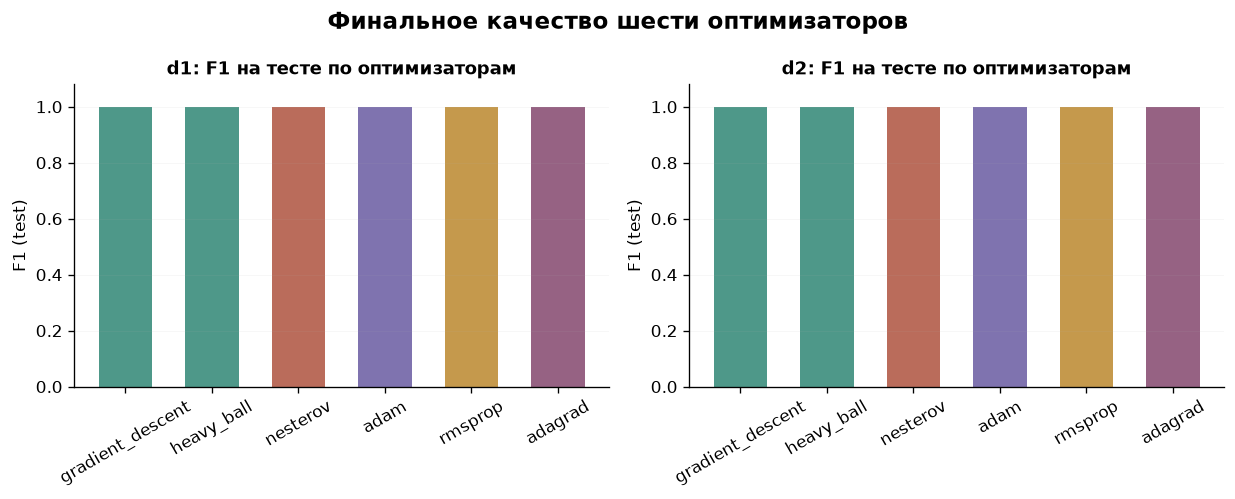

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
for ax, name in zip(axes, ("d1", "d2")):
    sub = cmp_frames[name]
    plotting.bar_comparison(
        ax,
        list(sub["method"]),
        list(sub["test_f1"]),
        ylabel="F1 (test)",
        title=f"{name}: F1 на тесте по оптимизаторам",
    )
    ax.set_ylim(0.0, 1.08)
fig.suptitle("Финальное качество шести оптимизаторов", fontsize=14, fontweight="bold")
plt.show()

Все методы дают высокий F1; сравниваем скорость по loss-кривым на d2

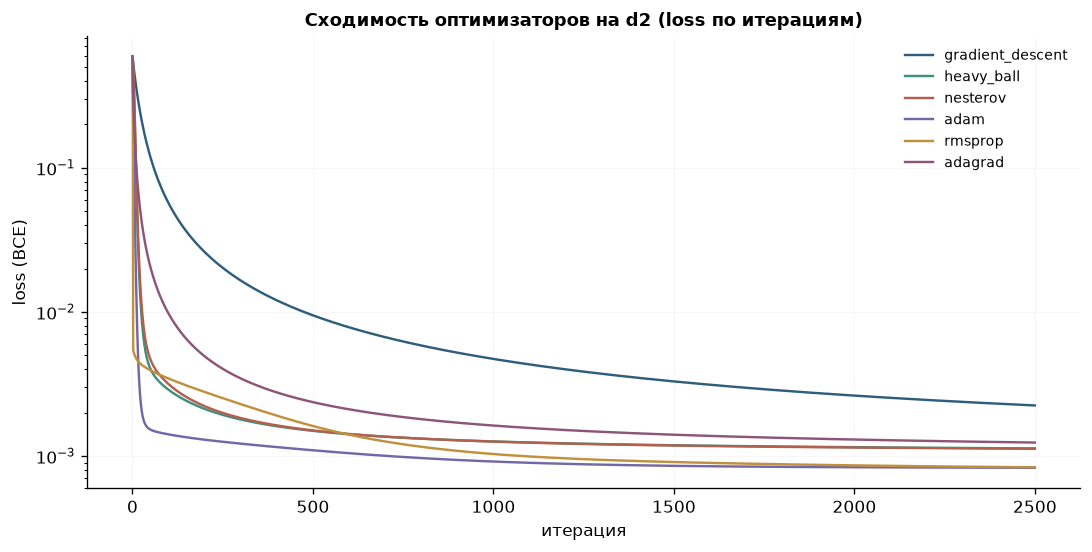

In [4]:
conv_results = {}
for method in ALL_METHODS:
    clf = nn.MLPClassifier(
        hidden_dim=HIDDEN_DIM,
        activation="tanh",
        method=method,
        learning_rate=LR,
        max_iter=MAX_ITER,
        l2=1e-4,
        seed=SEED,
        log_trajectory=True,
    )
    # load_dataset уже возвращает стандартизованные train-признаки.
    sp = datasets.load_dataset(D2, seed=SEED)
    Xs = np.asarray(sp.x_train)
    clf.fit(Xs, np.asarray(sp.y_train))
    conv_results[method] = clf.optimizer_result_

fig, ax = plt.subplots(figsize=(9.2, 4.7))
plotting.plot_convergence(
    ax,
    conv_results,
    key="f",
    title="Сходимость оптимизаторов на d2 (loss по итерациям)",
    ylabel="loss (BCE)",
)
plt.show()

**Вывод.** Adam/RMSProp и импульсные методы сходятся быстрее GD. Adagrad
замедляется из-за накопления квадратов градиента

### 2.1. Устойчивость по random seed

Пять seed'ов для Adam, Heavy-Ball и Nesterov: проверяем разброс F1/loss

test_f1                    loss                           
              mean  std  min  max     mean      std      min      max
method                                                               
adam           1.0  0.0  1.0  1.0  0.00085  0.00003  0.00082  0.00088
heavy_ball     1.0  0.0  1.0  1.0  0.00119  0.00006  0.00113  0.00128
nesterov       1.0  0.0  1.0  1.0  0.00118  0.00006  0.00113  0.00127

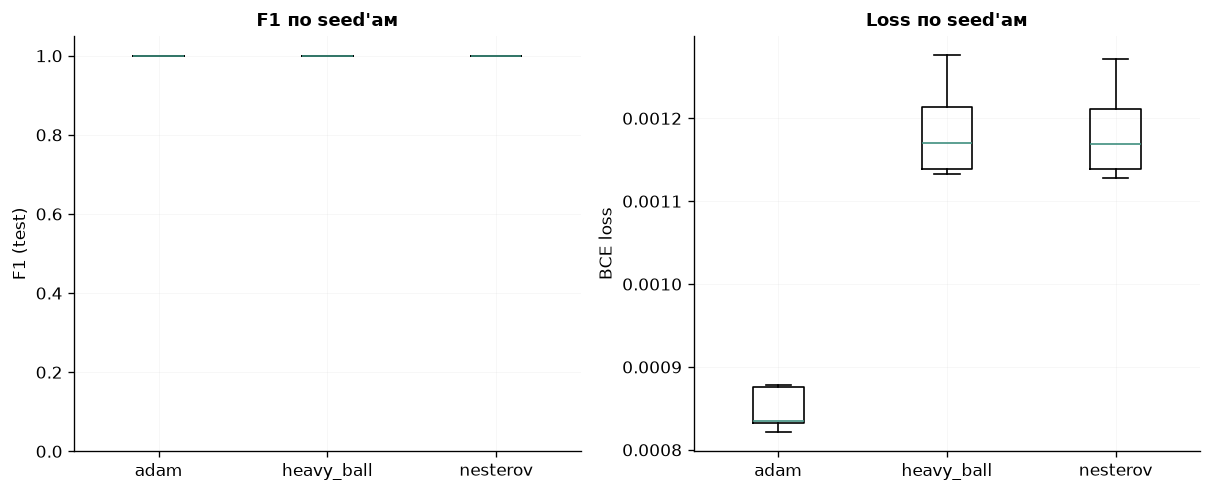

In [5]:
stability_rows = studies.optimizer_stability(
    D2,
    methods=("adam", "heavy_ball", "nesterov"),
    seeds=(1, 2, 3, 4, 5),
    hidden_dim=HIDDEN_DIM,
    learning_rate=LR,
    max_iter=1800,
    l2=1e-4,
)
stability = pd.DataFrame(stability_rows)
stability_summary = (
    stability.groupby("method")[["test_f1", "loss"]].agg(["mean", "std", "min", "max"]).round(5)
)
display(stability_summary)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
methods = ["adam", "heavy_ball", "nesterov"]
axes[0].boxplot(
    [stability[stability["method"] == m]["test_f1"] for m in methods], tick_labels=methods
)
axes[0].set_title("F1 по seed'ам")
axes[0].set_ylabel("F1 (test)")
axes[0].set_ylim(0.0, 1.05)
axes[1].boxplot([stability[stability["method"] == m]["loss"] for m in methods], tick_labels=methods)
axes[1].set_title("Loss по seed'ам")
axes[1].set_ylabel("BCE loss")
plt.show()

## 3. Расписания скорости обучения

Сравниваем `constant`, `step`, `exponential`, `cosine`, `cosine+warmup`
Метод: GD, потому что он сильнее всего зависит от расписания `lr`

In [6]:
SCHEDULE_CONFIGS = [
    ("constant", dict(schedule="constant", warmup_steps=0)),
    ("step", dict(schedule="step", warmup_steps=0)),
    ("exponential", dict(schedule="exponential", warmup_steps=0)),
    ("cosine", dict(schedule="cosine", warmup_steps=0)),
    ("cosine+warmup", dict(schedule="cosine", warmup_steps=100)),
]
SCHED_ITERS = 1500

sched_results = {}
sched_rows = []
sp = datasets.load_dataset(D2, seed=SEED)
Xs = np.asarray(sp.x_train)
ys = np.asarray(sp.y_train)

for label, schedule_kwargs in SCHEDULE_CONFIGS:
    clf = nn.MLPClassifier(
        hidden_dim=HIDDEN_DIM,
        activation="tanh",
        method="gradient_descent",
        learning_rate=0.2,
        max_iter=SCHED_ITERS,
        l2=1e-4,
        seed=SEED,
        schedule_iterations=SCHED_ITERS,
        log_trajectory=True,
        **schedule_kwargs,
    )
    clf.fit(Xs, ys)
    sched_results[label] = clf.optimizer_result_
    res = datasets.train_binary_dataset(
        D2,
        hidden_dim=HIDDEN_DIM,
        method="gradient_descent",
        learning_rate=0.2,
        max_iter=SCHED_ITERS,
        activation="tanh",
        l2=1e-4,
        seed=SEED,
        schedule_iterations=SCHED_ITERS,
        **schedule_kwargs,
    )
    sched_rows.append(
        {"расписание": label, "F1 (test)": res.test_metrics["f1"], "итог. loss": clf.loss_}
    )

sched_table = pd.DataFrame(sched_rows).set_index("расписание")
sched_table.style.format({"F1 (test)": "{:.4f}", "итог. loss": "{:.5f}"})

,F1 (test),итог. loss
расписание,,
constant,1.0000,0.00125
step,1.0000,0.00363
exponential,1.0000,0.00152
cosine,1.0000,0.00154
cosine+warmup,1.0000,0.00158


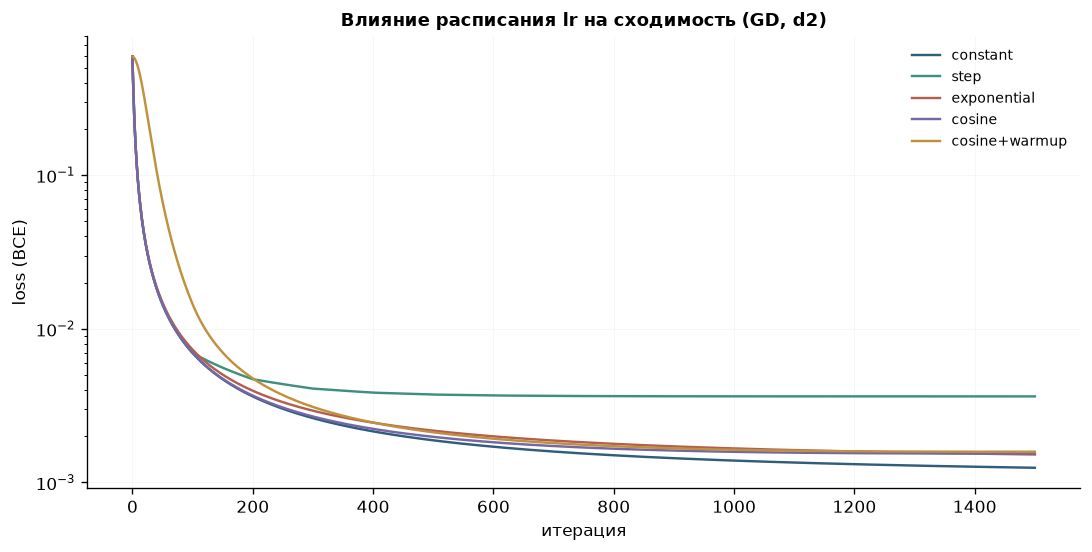

In [7]:
fig, ax = plt.subplots(figsize=(9.2, 4.7))
plotting.plot_convergence(
    ax,
    sched_results,
    key="f",
    title="Влияние расписания lr на сходимость (GD, d2)",
    ylabel="loss (BCE)",
)
plt.show()

**Вывод.** Затухающие schedules стартуют агрессивно и мягче сходятся в конце;
warmup снижает риск резкого старта

## 4. Ablation по регуляризации (L2)

Проверяем L2 на d1/d2. Для d3 оставляем умеренную регуляризацию как защиту от
переобучения

In [8]:
L2_VALUES = (0.0, 1e-5, 1e-4, 1e-3, 1e-2)

reg_frames = {}
for name, path in (("d1", D1), ("d2", D2)):
    rows = studies.regularization_ablation(
        path,
        l2_values=L2_VALUES,
        hidden_dim=HIDDEN_DIM,
        method="adam",
        learning_rate=LR,
        max_iter=2500,
        seed=SEED,
    )
    df = pd.DataFrame(rows)
    df["dataset"] = name
    reg_frames[name] = df

reg = pd.concat(reg_frames.values(), ignore_index=True)
reg_pivot = reg.pivot(index="l2", columns="dataset", values="test_f1")
reg_pivot.columns = [f"F1 ({c})" for c in reg_pivot.columns]
reg_pivot.style.format("{:.4f}").background_gradient(cmap="Greens")

,F1 (d1),F1 (d2)
l2,,
0.000000,1.0000,1.0000
0.000010,1.0000,1.0000
0.000100,1.0000,1.0000
0.001000,1.0000,1.0000
0.010000,1.0000,1.0000


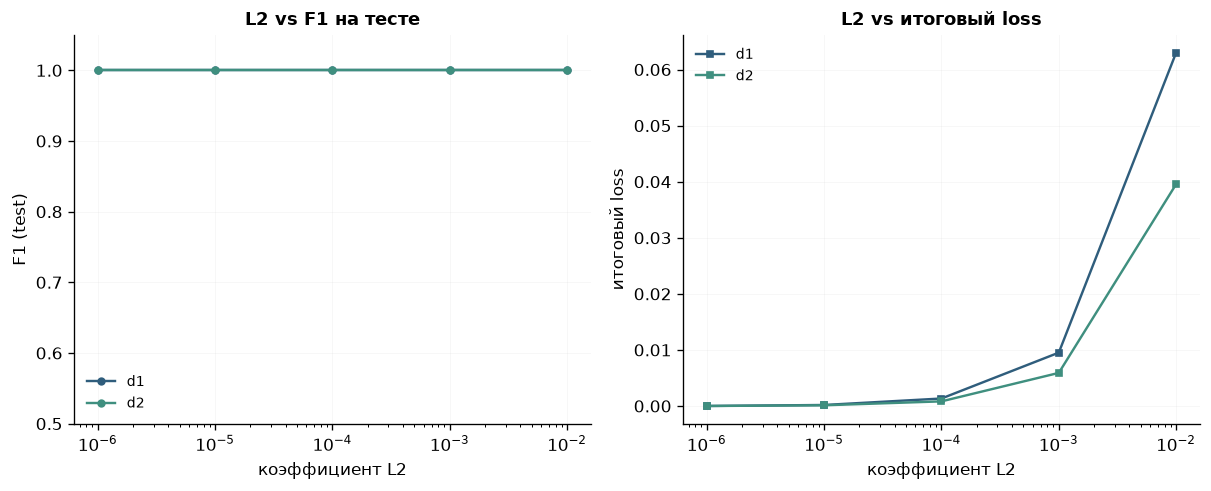

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))

axes[0].set_title("L2 vs F1 на тесте")
for name in ("d1", "d2"):
    sub = reg_frames[name].sort_values("l2")
    axes[0].plot(sub["l2"].clip(lower=1e-6), sub["test_f1"], marker="o", label=name)
axes[0].set_xscale("log")
axes[0].set_xlabel("коэффициент L2")
axes[0].set_ylabel("F1 (test)")
axes[0].set_ylim(0.5, 1.05)
axes[0].legend()

axes[1].set_title("L2 vs итоговый loss")
for name in ("d1", "d2"):
    sub = reg_frames[name].sort_values("l2")
    axes[1].plot(sub["l2"].clip(lower=1e-6), sub["loss"], marker="s", label=name)
axes[1].set_xscale("log")
axes[1].set_xlabel("коэффициент L2")
axes[1].set_ylabel("итоговый loss")
axes[1].legend()

plt.show()

**Вывод.** `L2=1e-4` почти не снижает F1 и ограничивает веса. `1e-2` уже мешает
оптимизации

### 4.1. Ablation по инициализации

Для `tanh` базовый выбор: Xavier. Проверяем Xavier против He по F1/loss

dataset,d1,d2
initialization,,
he,1.0000,1.0000
xavier,1.0000,1.0000


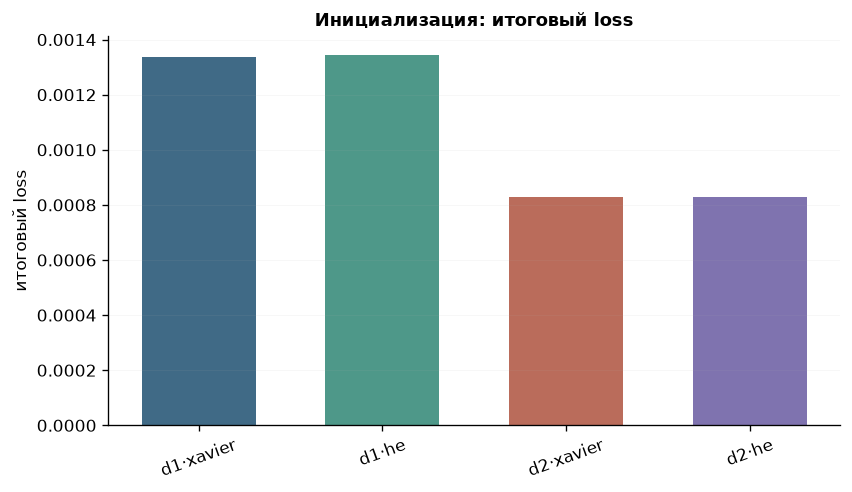

In [10]:
init_frames = {}
for name, path in (("d1", D1), ("d2", D2)):
    rows = studies.initialization_ablation(
        path,
        initializations=("xavier", "he"),
        hidden_dim=HIDDEN_DIM,
        method="adam",
        learning_rate=LR,
        max_iter=2500,
        seed=SEED,
        l2=1e-4,
    )
    df = pd.DataFrame(rows)
    df["dataset"] = name
    init_frames[name] = df

init_ablation = pd.concat(init_frames.values(), ignore_index=True)
display(
    init_ablation.pivot(index="initialization", columns="dataset", values="test_f1")
    .style.format("{:.4f}")
    .background_gradient(cmap="Greens", axis=None)
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
labels = [f"{row.dataset}·{row.initialization}" for row in init_ablation.itertuples()]
plotting.bar_comparison(
    ax,
    labels,
    list(init_ablation["loss"]),
    ylabel="итоговый loss",
    title="Инициализация: итоговый loss",
    highlight_max=False,
)
ax.tick_params(axis="x", rotation=20)
plt.show()

## 5. Сравнение с эталонами (sklearn / PyTorch)

Сравнение с `sklearn.MLPClassifier` и optional PyTorch MLP той же ширины

In [11]:
baseline_rows = []
for name, path in (("d1", D1), ("d2", D2)):
    ours = datasets.train_binary_dataset(
        path,
        hidden_dim=HIDDEN_DIM,
        method="adam",
        learning_rate=LR,
        max_iter=5000,
        activation="tanh",
        l2=1e-4,
        seed=SEED,
    )
    baseline_rows.append(
        {
            "датасет": name,
            "реализация": "optlib (наша)",
            "F1 (test)": ours.test_metrics["f1"],
            "accuracy": ours.test_metrics["accuracy"],
        }
    )
    sk = studies.sklearn_mlp_baseline(path, hidden_dim=HIDDEN_DIM, max_iter=1000, seed=SEED)
    if sk is not None:
        baseline_rows.append(
            {
                "датасет": name,
                "реализация": "sklearn MLP",
                "F1 (test)": sk["test_f1"],
                "accuracy": sk["test_accuracy"],
            }
        )
    torch = studies.torch_mlp_baseline(
        path,
        hidden_dim=HIDDEN_DIM,
        learning_rate=LR,
        epochs=500,
        seed=SEED,
    )
    if torch is not None:
        baseline_rows.append(
            {
                "датасет": name,
                "реализация": "PyTorch MLP",
                "F1 (test)": torch["test_f1"],
                "accuracy": torch["test_accuracy"],
            }
        )

baseline = pd.DataFrame(baseline_rows).set_index(["датасет", "реализация"])
baseline.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["F1 (test)"])

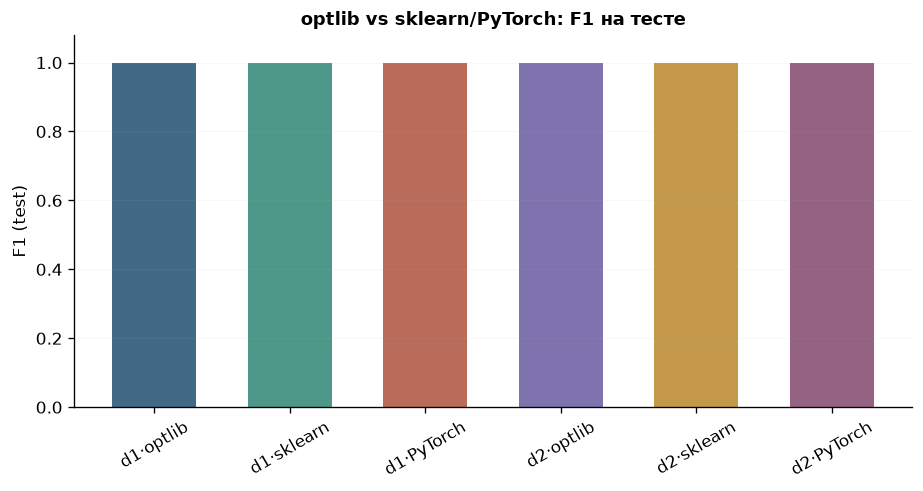

In [12]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
labels = [f"{i[0]}·{i[1].split()[0]}" for i in baseline.index]
plotting.bar_comparison(
    ax,
    labels,
    list(baseline["F1 (test)"]),
    ylabel="F1 (test)",
    title="optlib vs sklearn/PyTorch: F1 на тесте",
    highlight_max=False,
)
ax.set_ylim(0.0, 1.08)
plt.show()

**Вывод.** `optlib` находится в одном диапазоне качества со sklearn/PyTorch;
forward/backprop и оптимизаторы работают корректно

## 6. Выбор финальной конфигурации

Финальный конфиг:

| параметр | значение | обоснование |
|---|---|---|
| `method` | `adam` | самая быстрая и устойчивая сходимость |
| `hidden_dim` | `16` | достаточной ёмкости; запас под возможный multiclass d3 |
| `learning_rate` | `0.03` | в оптимальном диапазоне по loss/скорости |
| `max_iter` | `5000` | гарантированная сходимость для финальной модели |
| `activation` | `tanh` | гладкая граница решений, стабильное обучение |
| `initialization` | `xavier` | согласована с `tanh`, подтверждена ablation |
| `l2` | `1e-4` | умеренная регуляризация → лучше обобщение на d3 |

Этот конфиг используется в итоговой ячейке и сохраняется для live-прогона d3

## 7. Итоговая взвешенная метрика F1 (с заделом под d3) и сохранение модели

Ячейка считает weighted F1, работает без d3 и автоматически добавляет d3 при
заданном `D3_PATH`. Сохранённая binary-модель проверяется live, если формат d3
совместим; иначе используется OVR fallback

In [13]:
from pathlib import Path

# --- Конфигурация итоговой оценки --------------------------------------------
WEIGHTS = {"d1": 0.3, "d2": 0.3, "d3": 0.4}
THRESHOLD = 0.55
BEST = dict(
    hidden_dim=16,
    method="adam",
    learning_rate=0.03,
    max_iter=5000,
    activation="tanh",
    initialization="xavier",
    l2=1e-4,
    seed=42,
)

# === d3: на защите укажите путь к закрытому датасету ИЛИ скачайте по id Drive ==
#   D3_PATH = "data/third_dataset.csv"
#   или: D3_PATH = optlib.datasets.download("<gdrive_id>", "data/third_dataset.csv")
D3_PATH = None

score = studies.weighted_f1_score({"d1": D1, "d2": D2, "d3": D3_PATH}, weights=WEIGHTS, **BEST)
score_table = pd.DataFrame(score["rows"])
display(
    score_table[["dataset", "mode", "class_count", "weight", "test_f1", "contribution"]]
    .rename(columns={"dataset": "датасет", "test_f1": "F1", "contribution": "вклад"})
    .set_index("датасет")
    .style.format({"weight": "{:.2f}", "F1": "{:.4f}", "вклад": "{:.4f}"})
)

print(f"Итоговый взвешенный F1 = {score['total']:.4f}   (порог {THRESHOLD})")
print("Статус:", "ПРОЙДЕНО (PASS)" if score["total"] >= THRESHOLD else "НЕ ПРОЙДЕНО (FAIL)")
if score["missing"]:
    print("Пока отсутствуют датасеты:", ", ".join(score["missing"]))

,mode,class_count,weight,F1,вклад
датасет,,,,,
d1,binary,2,0.30,1.0000,0.3000
d2,binary,2,0.30,1.0000,0.3000


Итоговый взвешенный F1 = 0.6000   (порог 0.55)
Статус: ПРОЙДЕНО (PASS)
Пока отсутствуют датасеты: d3


In [14]:
# Сохраняем веса финальной модели на d1 для воспроизводимости и live-прогона.
# (на защите: load_binary_dataset_model(path) -> model.evaluate_path('data/third_dataset.csv'))
final_model = datasets.train_binary_dataset(D1, **BEST).model
Path("artifacts").mkdir(exist_ok=True)
# Веса сохраняются в формате .npz; задаём явное имя файла, чтобы путь был
# однозначным как для сохранения, так и для последующей загрузки.
model_path = "artifacts/final_model_d1.npz"
final_model.save(model_path)

# Проверяем, что модель корректно загружается обратно
reloaded = datasets.load_binary_dataset_model(model_path)
check = reloaded.evaluate_path(D1)
print(f"Модель сохранена в {model_path}")
print(
    f"Контрольный прогон загруженной модели на d1: F1 = {check['f1']:.4f}, "
    f"accuracy = {check['accuracy']:.4f}"
)

if D3_PATH and Path(D3_PATH).exists():
    try:
        live = reloaded.evaluate_path(D3_PATH)
        print(f"Live evaluate сохранённой binary-модели на d3: F1 = {live['f1']:.4f}")
    except ValueError as exc:
        print("Сохранённая binary-модель несовместима с d3:", exc)
        print(
            "Для такого d3 используйте таблицу weighted_f1_score выше: она обучает OVR-модель при multiclass."
        )

Модель сохранена в artifacts/final_model_d1.npz
Контрольный прогон загруженной модели на d1: F1 = 1.0000, accuracy = 1.0000


## Выводы

1. Adam/RMSProp и импульсные методы сходятся быстрее GD; F1 у всех высокий
2. `cosine/step/exponential` и warmup улучшают поведение GD
3. `L2=1e-4` и Xavier: устойчивый выбор для d3
4. `optlib` совпадает по уровню качества со sklearn/PyTorch baseline
5. Финальная модель сохранена; d3 поддержан через live-evaluate или OVR fallback